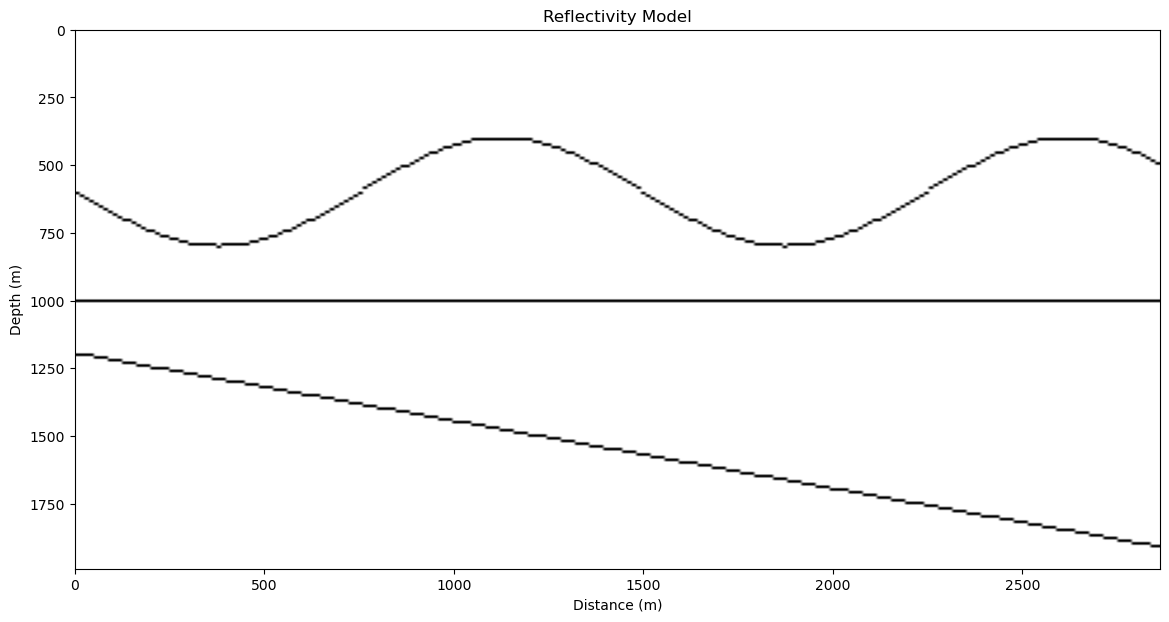

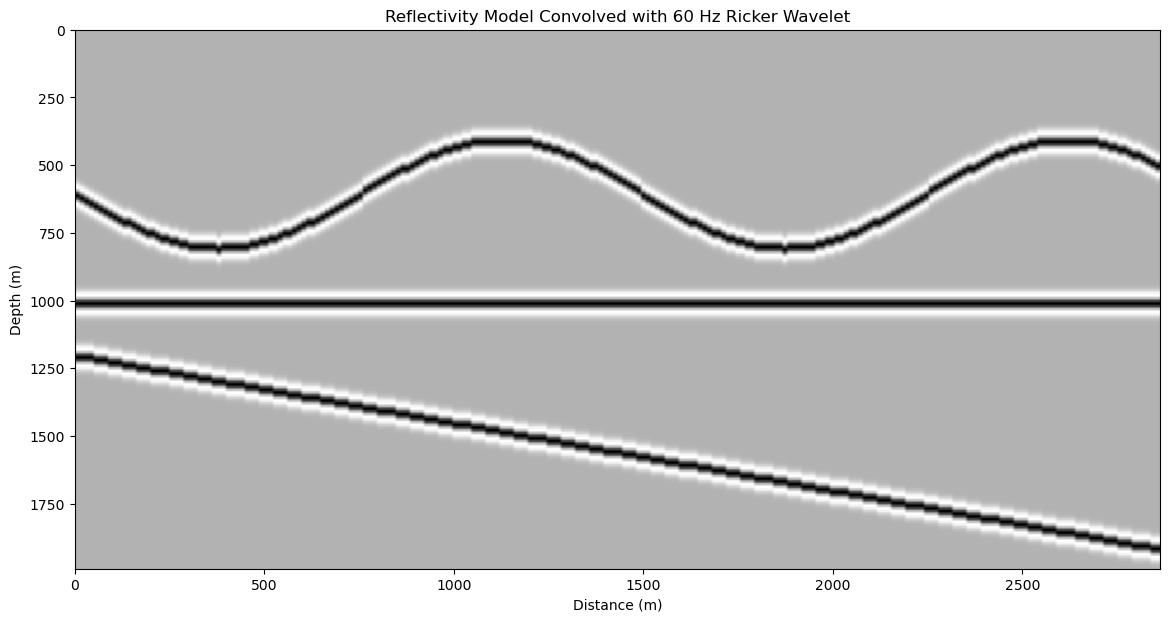

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve

# --- 1. Grid and Geometry Setup ---
nx, nz = 230, 200
dx, dz = 12.5, 10
x = np.arange(nx) * dx
z = np.arange(nz) * dz

# --- 2. Create Reflectivity Model (R1) ---
R1 = np.zeros((nz, nx))

# Layer 1: Sinusoidal interface
z1 = 600 + 200 * np.sin(2 * np.pi * x / 1500)
z1_idx = (z1 / dz).astype(int)

# Layer 2: Flat interface at 1000m
z2_idx = int(1000 / dz)

# Layer 3: Dipping interface
z3 = 1200 + 0.25 * x
z3_idx = (z3 / dz).astype(int)

# Fill the reflectivity matrix
for i in range(nx):
    # Apply Layer 1
    if 0 <= z1_idx[i] < nz:
        R1[z1_idx[i], i] = 1.0
    # Apply Layer 2
    if 0 <= z2_idx < nz:
        R1[z2_idx, i] = 1.0
    # Apply Layer 3
    if 0 <= z3_idx[i] < nz:
        R1[z3_idx[i], i] = 1.0

# --- 3. Wavelet and Convolution Functions ---
def ricker(f0, length, dt):
    """Generates a Ricker wavelet."""
    t = np.arange(-length/2, length/2, dt)
    y = (1 - 2*(np.pi*f0*t)**2) * np.exp(-(np.pi*f0*t)**2)
    return y

def convolve_reflectivity(R, wavelet):
    """Convolves each column of the reflectivity matrix with the wavelet."""
    nz, nx = R.shape
    convolved = np.zeros_like(R)
    for i in range(nx):
        convolved[:, i] = convolve(R[:, i], wavelet, mode='same')
    return convolved

# Generate 60 Hz Ricker wavelet
wavelet = ricker(60, 0.08, 0.002)

# Perform convolution
R1_conv = convolve_reflectivity(R1, wavelet)

# --- 4. Visualization ---
# Plot 1: Reflectivity Model
plt.figure(figsize=(14, 7), facecolor='white')
plt.imshow(R1, cmap='gray_r', aspect='auto',
           extent=[x[0], x[-1], z[-1], z[0]])
plt.title('Reflectivity Model')
plt.xlabel('Distance (m)')
plt.ylabel('Depth (m)')
plt.grid(False)
plt.show()

# Plot 2: Convolved Model
plt.figure(figsize=(14, 7), facecolor='white')
plt.imshow(R1_conv, cmap='gray_r', aspect='auto',
           extent=[x[0], x[-1], z[-1], z[0]])
plt.title('Reflectivity Model Convolved with 60 Hz Ricker Wavelet')
plt.xlabel('Distance (m)')
plt.ylabel('Depth (m)')
plt.grid(False)
plt.show()

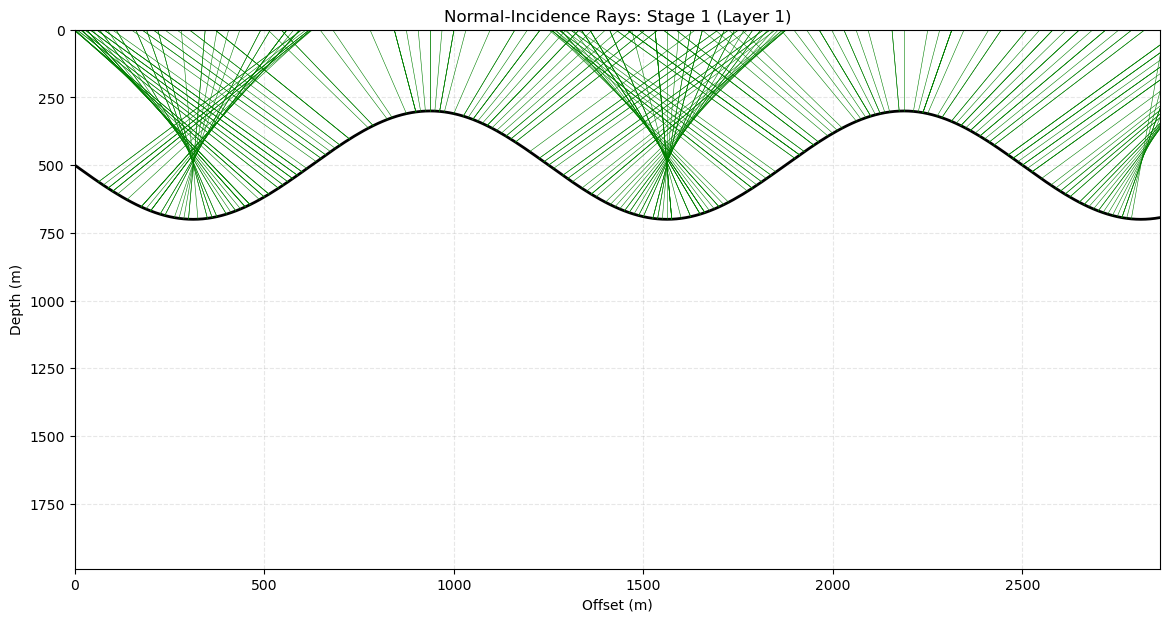

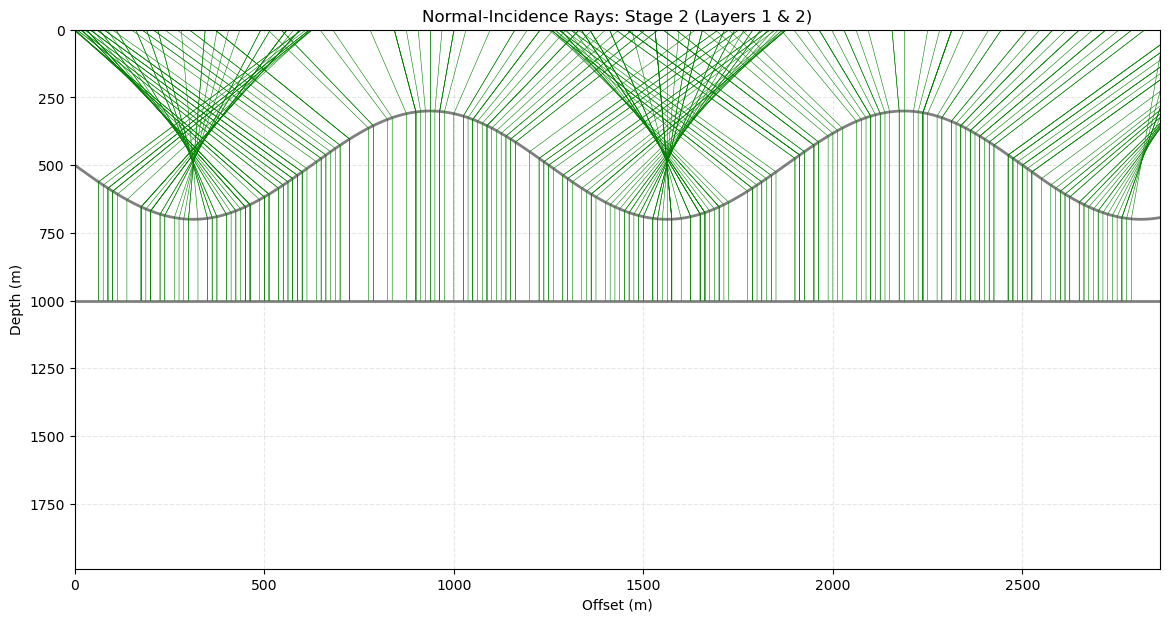

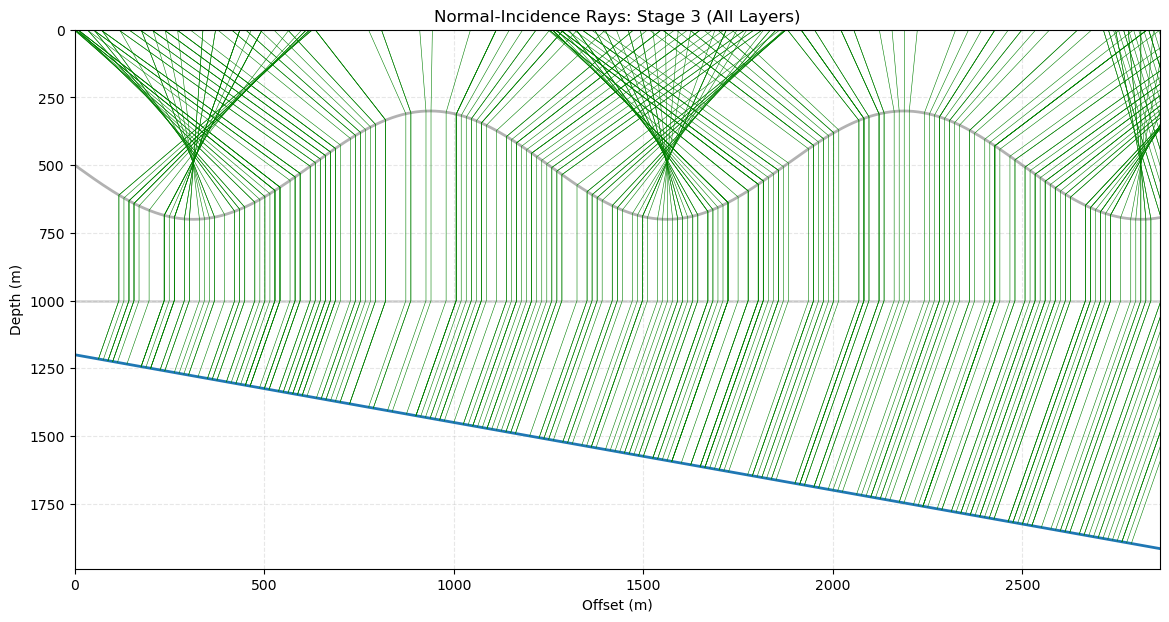

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Geometry and Layer Definition ---
# Using grid parameters defined in Cell 1
reflector1_z = (50 + 20 * np.sin(2 * np.pi * np.arange(nx) / 100)) * dz
reflector2_z = np.full(nx, 1000.0)
reflector3_z = 1200 + 0.25 * x

# --- 2. Normal Vector Calculations ---
# Normals for Layer 1 (Surface layer)
dzdx1 = np.gradient(reflector1_z, dx)
nx_n1, nz_n1 = -dzdx1, np.ones_like(dzdx1)
norm1 = np.sqrt(nx_n1**2 + nz_n1**2)
nx_n1 /= norm1; nz_n1 /= norm1

# Normals for Layer 3 (Deepest dipping layer)
dzdx3 = 0.25 * np.ones_like(x)
nx_n3, nz_n3 = -dzdx3, np.ones_like(dzdx3)
norm3 = np.sqrt(nx_n3**2 + nz_n3**2)
nx_n3 /= norm3; nz_n3 /= norm3

# --- 3. Ray Configuration ---
num_rays = 300
np.random.seed(0)
ray_indices = np.sort(np.random.choice(np.arange(5, nx-5), size=num_rays, replace=True))

def plot_setup(title):
    """Initializes a standard plot for ray tracing."""
    plt.figure(figsize=(14, 7), facecolor='white')
    ax = plt.gca()
    ax.set_facecolor('white')
    ax.set_xlim(x[0], x[-1])
    ax.set_ylim(z[-1], 0)
    ax.set_xlabel('Offset (m)')
    ax.set_ylabel('Depth (m)')
    ax.set_title(title)
    ax.grid(True, linestyle='--', alpha=0.3)
    return ax

# --- 4. Plotting Stages ---

# STAGE 1: Only Layer 1 rays
ax1 = plot_setup('Normal-Incidence Rays: Stage 1 (Layer 1)')
ax1.plot(x, reflector1_z, 'k', linewidth=2)
for i in ray_indices:
    x0, z0 = x[i], reflector1_z[i]
    scale = z0 / nz_n1[i]
    ax1.plot([x0, x[i] - nx_n1[i]*scale], [z0, 0], color='green', linewidth=0.4)
plt.show()

# STAGE 2: Layer 1 + Layer 2 rays
ax2 = plot_setup('Normal-Incidence Rays: Stage 2 (Layers 1 & 2)')
ax2.plot(x, reflector1_z, 'k', linewidth=2, alpha=0.5)
ax2.hlines(1000, x[0], x[-1], colors='gray', linewidth=2)
for i in ray_indices:
    # Ray starts at Layer 2, passes through Layer 1
    x0, z0 = x[i], reflector2_z[i]
    z1_int = np.interp(x[i], x, reflector1_z)
    nxn1 = np.interp(x[i], x, nx_n1)
    nzn1 = np.interp(x[i], x, nz_n1)
    scale = z1_int / nzn1
    ax2.plot([x[i], x[i], x[i] - nxn1*scale], [z0, z1_int, 0], color='green', linewidth=0.4)
plt.show()

# STAGE 3: All layers (Complete Model)
ax3 = plot_setup('Normal-Incidence Rays: Stage 3 (All Layers)')
ax3.plot(x, reflector1_z, 'k', linewidth=2, alpha=0.3)
ax3.hlines(1000, x[0], x[-1], colors='gray', linewidth=2, alpha=0.3)
ax3.plot(x, reflector3_z, linewidth=2)
for i in ray_indices:
    # Ray starts at Layer 3, passes through 2 and 1
    x0, z0 = x[i], reflector3_z[i]
    scale3 = (z0 - 1000) / nz_n3[i]
    x2 = x0 - nx_n3[i] * scale3
    z1_int = np.interp(x2, x, reflector1_z)
    nxn1 = np.interp(x2, x, nx_n1)
    nzn1 = np.interp(x2, x, nz_n1)
    scale1 = z1_int / nzn1
    ax3.plot([x0, x2, x2, x2 - nxn1*scale1], [z0, 1000, z1_int, 0], color='green', linewidth=0.4)
plt.show()

Calculating Post-Stack Time Migration...


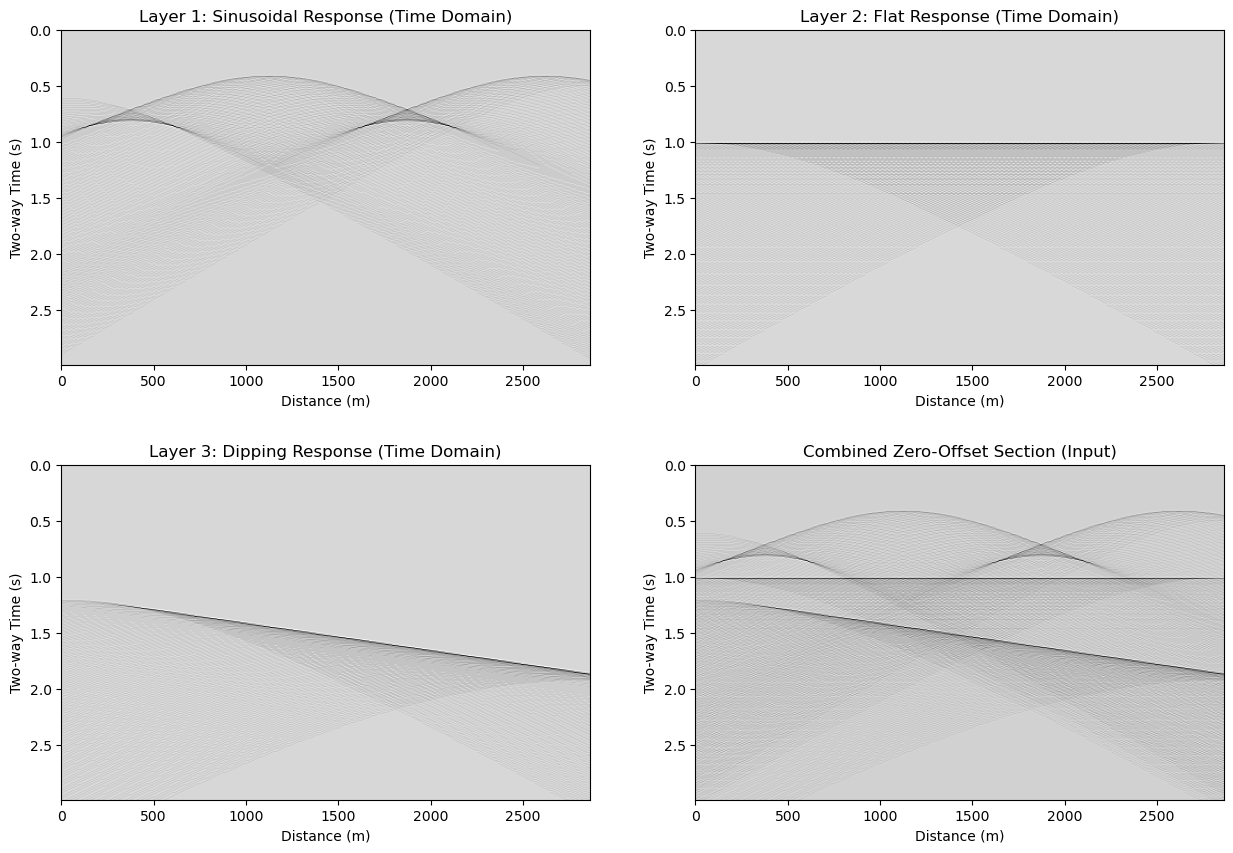

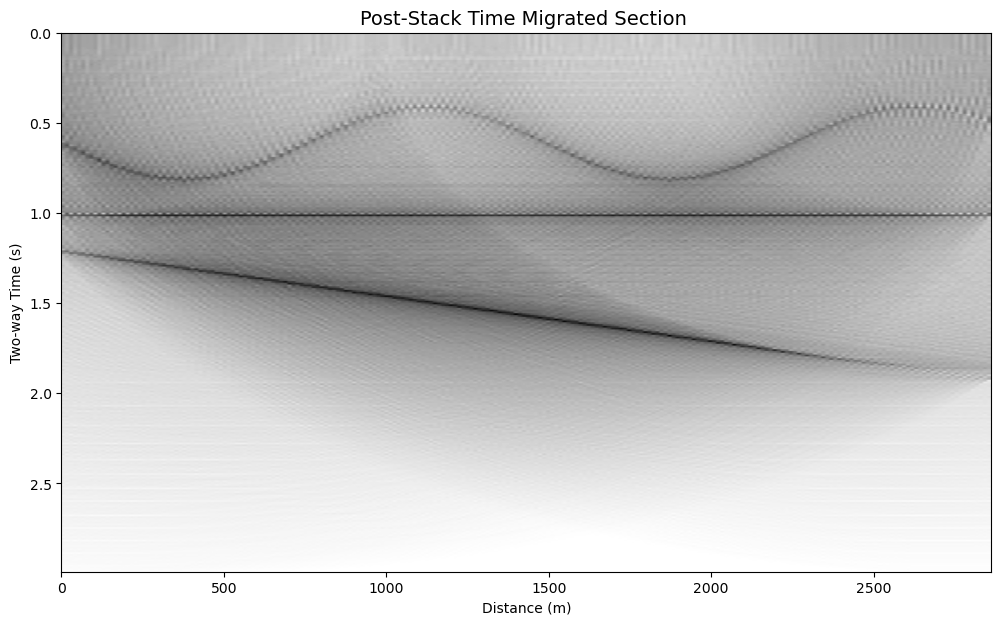

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve

# --- 1. Basic Setup ---
nx, nt, nz = 230, 300, 200
dx, dt, dz = 12.5, 0.01, 10.0
v = 2000.0  # Velocity for modeling and migration

x = np.arange(nx) * dx
t = np.arange(nt) * dt
z = np.arange(nz) * dz

# 60 Hz Ricker wavelet
t_w = np.arange(-0.04, 0.04, dt)
wavelet = (1 - 2*(np.pi*60*t_w)**2) * np.exp(-(np.pi*60*t_w)**2)

# --- 2. Modeling Function ---
def generate_diffractions(z_profile):
    """Creates hyperbolic diffractions for a given depth interface."""
    section = np.zeros((nt, nx))
    for i in range(0, nx, 2): 
        t0 = (2 * z_profile[i] / v)
        t_hyp = np.sqrt(t0**2 + (2 * (x - x[i]) / v)**2)
        it_indices = (t_hyp / dt).astype(int)
        valid = np.where(it_indices < nt)[0]
        section[it_indices[valid], valid] += 1.0
    
    for i in range(nx):
        section[:, i] = convolve(section[:, i], wavelet, mode='same')
    return section

# Define 3 Layers
z1 = 600 + 200 * np.sin(2 * np.pi * x / 1500)
z2 = 1000 * np.ones_like(x)
z3 = 1200 + 0.25 * x

# Generate individual and combined responses (Time Domain)
S1 = generate_diffractions(z1)
S2 = generate_diffractions(z2)
S3 = generate_diffractions(z3)
final_zero_offset = S1 + S2 + S3

# --- 3. Migration Function (Time Domain) ---
def time_migration(data, v_mig):
    """Post-Stack Time Migration."""
    # Output is in Time (nt x nx)
    migrated_time = np.zeros((nt, nx))
    for it0 in range(nt):
        curr_t0 = t[it0]
        for ix in range(nx):
            dist_x = x - x[ix]
            # Travel time equation for PSTM: t^2 = t0^2 + (2*dx/v)^2
            t_mig = np.sqrt(curr_t0**2 + (2.0 * dist_x / v_mig)**2)
            it = (t_mig / dt).astype(int)
            valid = np.where((it >= 0) & (it < nt))[0]
            migrated_time[it0, ix] = np.sum(data[it[valid], valid])
    return migrated_time

print("Calculating Post-Stack Time Migration...")
time_migrated_result = time_migration(final_zero_offset, v)

# --- 4. Visualization ---

# Plot 1: Time Domain Responses (Before Migration)
fig1, axes = plt.subplots(2, 2, figsize=(15, 10), facecolor='white')
plt.subplots_adjust(hspace=0.3)

axes[0, 0].imshow(S1, cmap='gray_r', aspect='auto', extent=[0, x[-1], t[-1], 0])
axes[0, 0].set_title('Layer 1: Sinusoidal Response (Time Domain)')

axes[0, 1].imshow(S2, cmap='gray_r', aspect='auto', extent=[0, x[-1], t[-1], 0])
axes[0, 1].set_title('Layer 2: Flat Response (Time Domain)')

axes[1, 0].imshow(S3, cmap='gray_r', aspect='auto', extent=[0, x[-1], t[-1], 0])
axes[1, 0].set_title('Layer 3: Dipping Response (Time Domain)')

axes[1, 1].imshow(final_zero_offset, cmap='gray_r', aspect='auto', extent=[0, x[-1], t[-1], 0])
axes[1, 1].set_title('Combined Zero-Offset Section (Input)')

for ax in axes.flat:
    ax.set_xlabel('Distance (m)')
    ax.set_ylabel('Two-way Time (s)')
plt.show()

# Plot 2: Time Domain (After Migration)
plt.figure(figsize=(12, 7), facecolor='white')
# Using t[-1] instead of z[-1] because we are in Time Domain
plt.imshow(time_migrated_result, cmap='gray_r', aspect='auto', extent=[0, x[-1], t[-1], 0])
plt.title('Post-Stack Time Migrated Section ', fontsize=14)
plt.xlabel('Distance (m)')
plt.ylabel('Two-way Time (s)')
plt.show()

Calculating Post-Stack Time Migration...
Calculating Kirchhoff Depth Migration...


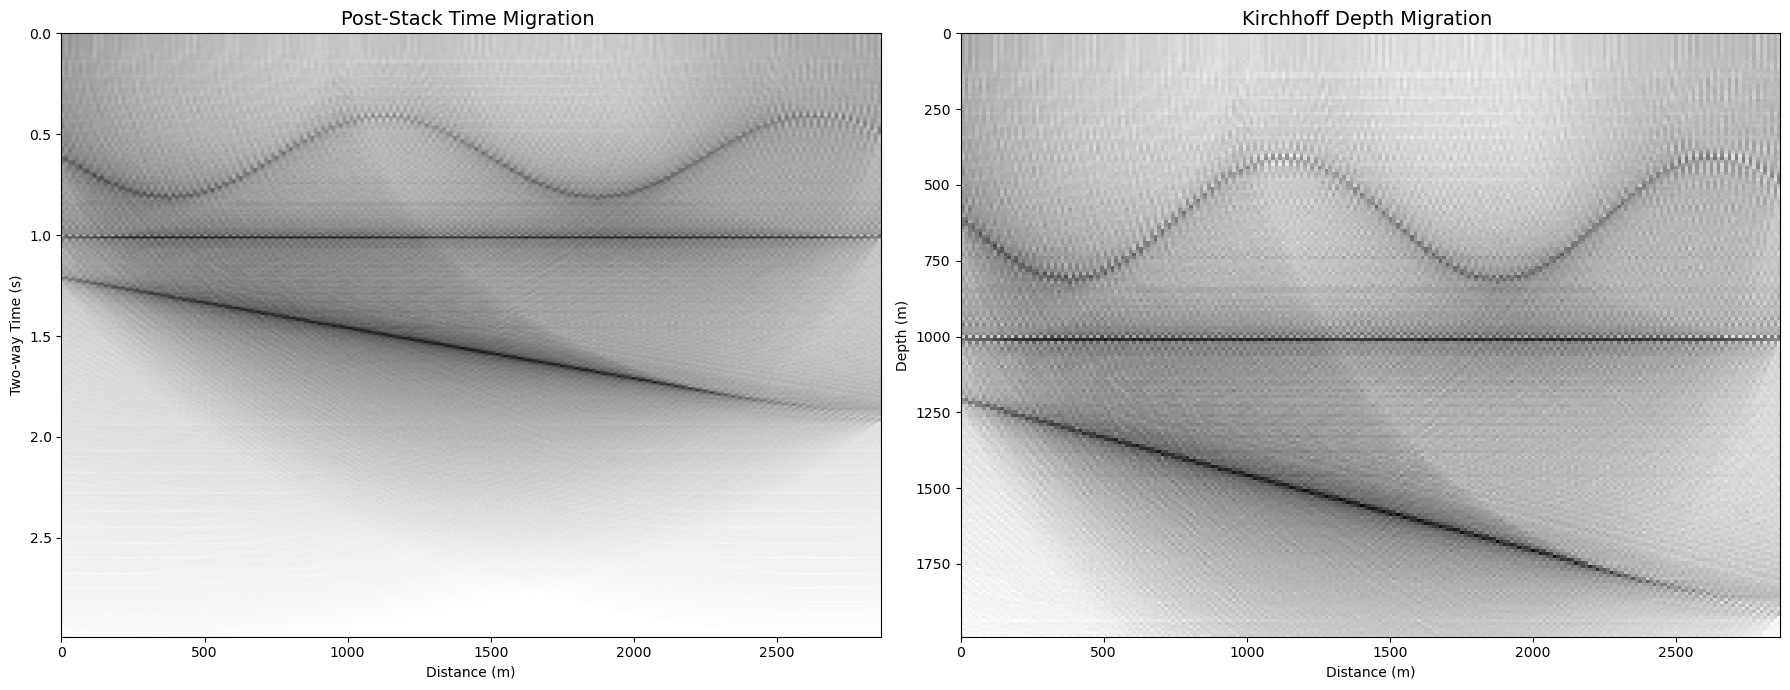

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve

# --- 1. Basic Setup (Ensure all variables are local to this cell) ---
nx, nt, nz = 230, 300, 200
dx, dt, dz = 12.5, 0.01, 10.0
v = 2000.0

x = np.arange(nx) * dx
t = np.arange(nt) * dt
z = np.arange(nz) * dz

# --- 2. Migration Functions ---

def post_stack_time_migration(data, v_mig):
    """Collapses energy to apex, output stays in Time Domain."""
    migrated_time = np.zeros((nt, nx))
    for it0 in range(nt):
        curr_t0 = t[it0]
        for ix in range(nx):
            dist_x = x - x[ix]
            # Time migration uses the same time units
            t_mig = np.sqrt(curr_t0**2 + (2.0 * dist_x / v_mig)**2)
            it = (t_mig / dt).astype(int)
            valid = np.where((it >= 0) & (it < nt))[0]
            migrated_time[it0, ix] = np.sum(data[it[valid], valid])
    return migrated_time

def kirchhoff_depth_migration(data, v_mig):
    """Maps energy from Time Domain to Depth Domain (meters)."""
    migrated_depth = np.zeros((nz, nx))
    for iz in range(nz):
        curr_z = z[iz]
        for ix in range(nx):
            dist_x = x - x[ix]
            # Depth migration converts distance to travel time
            t_mig = (2.0 * np.sqrt(curr_z**2 + dist_x**2)) / v_mig
            it = (t_mig / dt).astype(int)
            valid = np.where((it >= 0) & (it < nt))[0]
            migrated_depth[iz, ix] = np.sum(data[it[valid], valid])
    return migrated_depth

# --- 3. Processing ---
print("Calculating Post-Stack Time Migration...")
pstm_result = post_stack_time_migration(final_zero_offset, v)

print("Calculating Kirchhoff Depth Migration...")
kdm_result = kirchhoff_depth_migration(final_zero_offset, v)

# --- 4. Visualization (Side-by-Side Comparison) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), facecolor='white')

# Left Plot: Time Migration
ax1.imshow(pstm_result, cmap='gray_r', aspect='auto', extent=[0, x[-1], t[-1], 0])
ax1.set_title('Post-Stack Time Migration ', fontsize=14)
ax1.set_xlabel('Distance (m)')
ax1.set_ylabel('Two-way Time (s)')

# Right Plot: Depth Migration
ax2.imshow(kdm_result, cmap='gray_r', aspect='auto', extent=[0, x[-1], z[-1], 0])
ax2.set_title('Kirchhoff Depth Migration ', fontsize=14)
ax2.set_xlabel('Distance (m)')
ax2.set_ylabel('Depth (m)')

plt.tight_layout()
plt.show()